1. Analizar la calidad de datos, para lo que debes cargarlos y realizar un proceso exhaustivo de limpieza para eliminar valores faltantes, duplicados y atípicos que puedan afectar la calidad del modelo, si los hay.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Carga de datos
df = pd.read_excel('house_data.xlsx')

print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Información general
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  fl

In [4]:
# Nulos y duplicados
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print()
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'IDs duplicados: {df["id"].duplicated().sum()}')

=== Valores nulos por columna ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Filas duplicadas: 0
IDs duplicados: 177


In [5]:
# Inspeccionar un ejemplo de ID duplicado
ejemplo_duplicado = df[df['id'] == df[df['id'].duplicated()]['id'].iloc[0]]
print('Ejemplo de ID duplicado:')
print(ejemplo_duplicado[['id', 'date', 'price', 'bedrooms', 'sqft_living']])

Ejemplo de ID duplicado:
            id             date   price  bedrooms  sqft_living
93  6021501535  20140725T000000  430000         3         1580
94  6021501535  20141223T000000  700000         3         1580


Son ventas distintas de la misma propiedad (misma casa, diferente fecha y diferente precio). No son errores de datos, sino transacciones reales que ocurrieron en el período de análisis.

La decisión más razonable para un modelo predictivo: quedarnos solo con la venta más reciente de cada propiedad, ya que refleja mejor el valor actual de mercado.

In [6]:
# Convertir date a datetime para poder ordenar
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

# Quedarse solo con la venta más reciente por propiedad
print(f'Filas antes: {len(df)}')
df = df.sort_values('date', ascending=False).drop_duplicates(subset='id', keep='first')
print(f'Filas después: {len(df)}')
print(f'IDs duplicados restantes: {df["id"].duplicated().sum()}')

Filas antes: 21613
Filas después: 21436
IDs duplicados restantes: 0


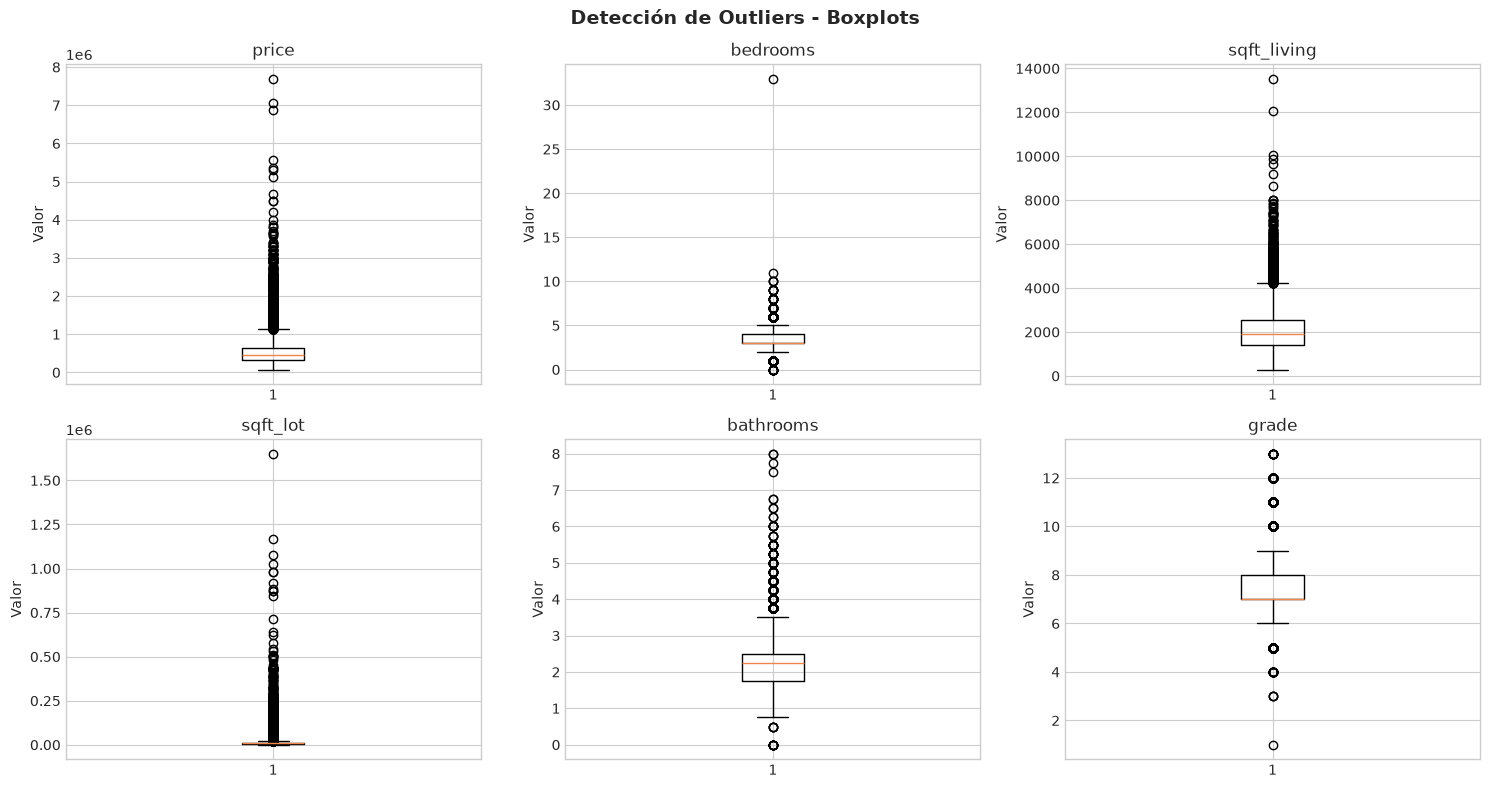

In [7]:
# Detección visual de outliers en variables clave
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

variables = ['price', 'bedrooms', 'sqft_living', 'sqft_lot', 'bathrooms', 'grade']

for ax, col in zip(axes.flatten(), variables):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.suptitle('Detección de Outliers - Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Tabla de outliers por variable usando IQR (factor 3)
def detectar_outliers_iqr(df, columna, factor=3):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - factor * IQR
    limite_sup = Q3 + factor * IQR
    outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

print('=== Resumen de Outliers por Variable ===\n')
for col in ['price', 'bedrooms', 'sqft_living', 'sqft_lot', 'bathrooms']:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
    print(f'{col}:')
    print(f'  Rango válido: [{lim_inf:.0f}, {lim_sup:.0f}]')
    print(f'  Cantidad de outliers: {len(outliers)}')
    if len(outliers) > 0 and len(outliers) <= 10:
        print(f'  Valores: {sorted(df[col][outliers.index].tolist())}')
    print()

=== Resumen de Outliers por Variable ===

price:
  Rango válido: [-635536, 1605402]
  Cantidad de outliers: 422

bedrooms:
  Rango válido: [0, 7]
  Cantidad de outliers: 24

sqft_living:
  Rango válido: [-1930, 5910]
  Cantidad de outliers: 74

sqft_lot:
  Rango válido: [-11929, 27665]
  Cantidad de outliers: 1765

bathrooms:
  Rango válido: [-0, 5]
  Cantidad de outliers: 64



In [9]:
# Eliminar outliers
print(f'Filas antes: {len(df)}')

def eliminar_outliers_iqr(df, columna, factor=3):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - factor * IQR
    limite_sup = Q3 + factor * IQR
    antes = len(df)
    df = df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)]
    print(f'{columna}: eliminadas {antes - len(df)} filas → {len(df)} restantes')
    return df

for col in ['price', 'bedrooms', 'sqft_living', 'sqft_lot', 'bathrooms']:
    df = eliminar_outliers_iqr(df, col)

print(f'\nFilas finales: {len(df)}')
print(f'Porcentaje retenido: {len(df)/21436*100:.1f}%')

Filas antes: 21436
price: eliminadas 422 filas → 21014 restantes
bedrooms: eliminadas 20 filas → 20994 restantes
sqft_living: eliminadas 32 filas → 20962 restantes
sqft_lot: eliminadas 1718 filas → 19244 restantes
bathrooms: eliminadas 1 filas → 19243 restantes

Filas finales: 19243
Porcentaje retenido: 89.8%


2. Realizar un análisis descriptivo de las variables para entender la distribución de los datos y detectar posibles relaciones entre las características y los precios. En esto debes incluir un análisis de correlaciones entre las variables principalmente con el precio de las casas, comenta acerca de las variables con mayor correlación, ¿tienen sentido?

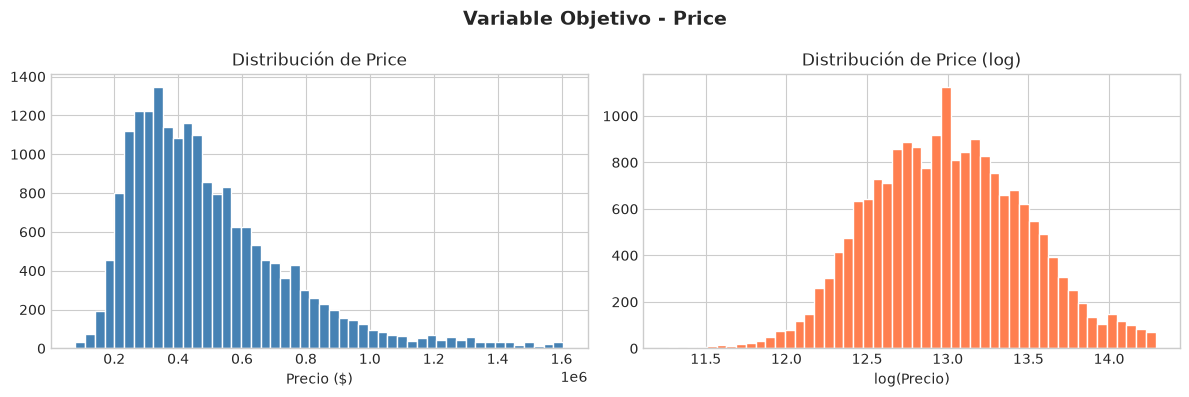

Media: $497,112
Mediana: $437,718
Mínimo: $78,000
Máximo: $1,605,000


In [10]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Price')
axes[0].set_xlabel('Precio ($)')

axes[1].hist(np.log1p(df['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución de Price (log)')
axes[1].set_xlabel('log(Precio)')

plt.suptitle('Variable Objetivo - Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Media: ${df["price"].mean():,.0f}')
print(f'Mediana: ${df["price"].median():,.0f}')
print(f'Mínimo: ${df["price"].min():,.0f}')
print(f'Máximo: ${df["price"].max():,.0f}')

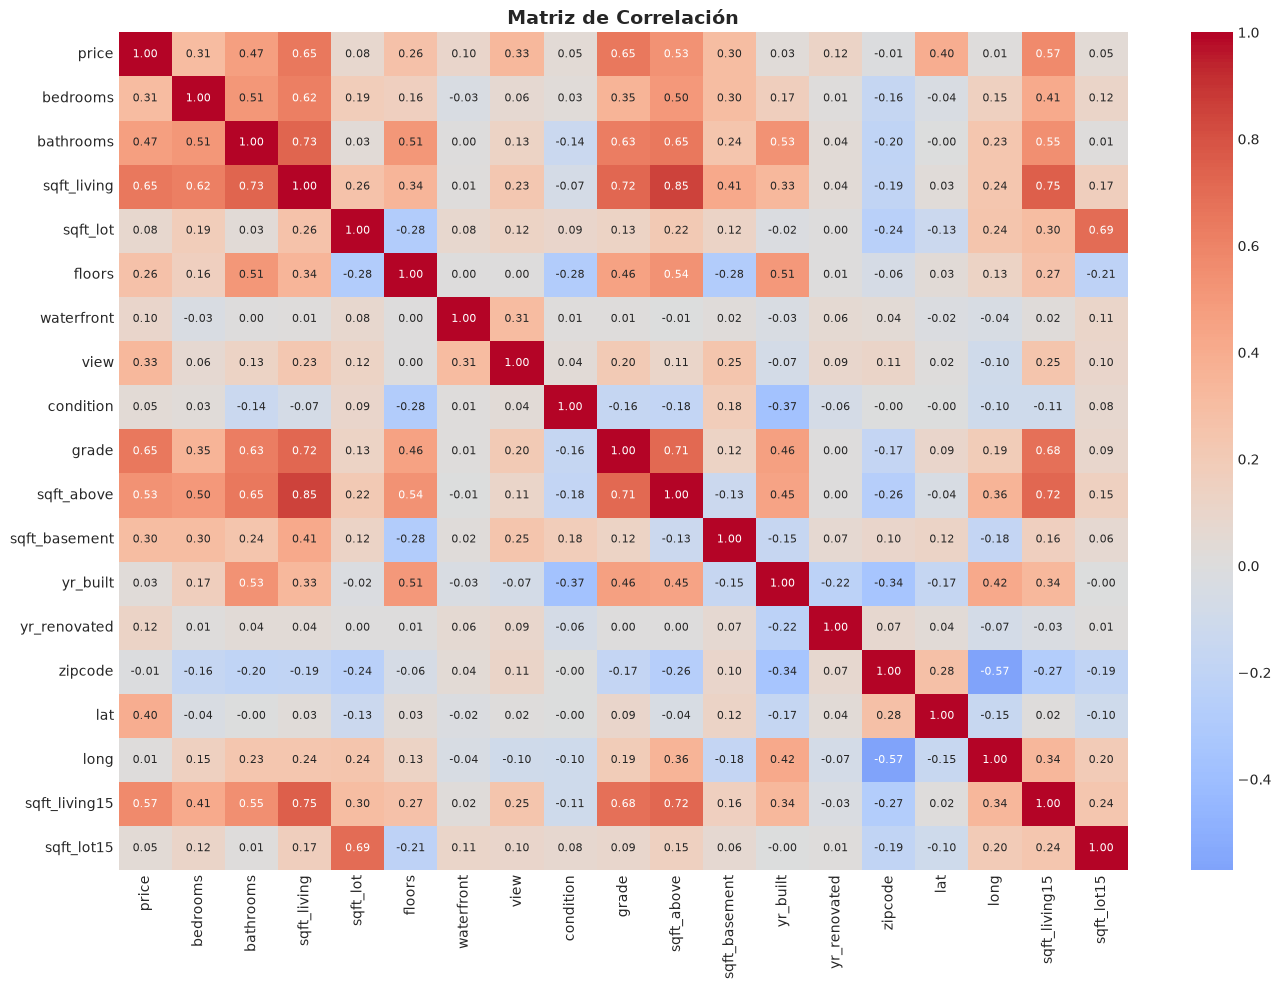

=== Correlación con Price ===
price            1.000
grade            0.653
sqft_living      0.646
sqft_living15    0.572
sqft_above       0.532
bathrooms        0.469
lat              0.399
view             0.333
bedrooms         0.312
sqft_basement    0.295
floors           0.265
yr_renovated     0.117
waterfront       0.098
sqft_lot         0.083
sqft_lot15       0.048
condition        0.048
yr_built         0.026
long             0.010
zipcode         -0.011
Name: price, dtype: float64


In [12]:
# Matriz de correlación usando df limpio
df_corr = df.drop(columns=['id', 'date'])

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones con price ordenadas
print('=== Correlación con Price ===')
print(corr_matrix['price'].sort_values(ascending=False).round(3))

Lectura de las correlaciones con Price
Variables con correlación alta (>0.5):
grade (0.653) — la calificación de calidad de construcción es el predictor más fuerte. Una casa mejor construida y terminada vale más, independientemente de su tamaño.
sqft_living (0.646) — Más espacio = más precio, relación directa y obvia.
sqft_living15 (0.572) — la superficie habitable de las 15 casas vecinas más cercanas. El vecindario importa casi tanto como la casa misma.
sqft_above (0.532) — superficie sobre el nivel del suelo (sin sótano). Muy correlacionada con sqft_living, lo que indica multicolinealidad — ambas miden casi lo mismo.

Variables con correlación moderada (0.3-0.5):
bathrooms (0.469) — más baños = mayor precio, también correlacionado con tamaño.
lat (0.399) — la latitud (ubicación norte-sur) importa más que la longitud. En King County, las zonas más al norte tienden a ser más costosas.
view (0.333) y bedrooms (0.312) — aportan pero con menor fuerza.

Variables con correlación baja (<0.15):
yr_built (0.026), condition (0.048), waterfront (0.098) — sorprendentemente bajas. Especialmente yr_built — la antigüedad de la casa casi no explica el precio directamente (probablemente porque las renovaciones compensan la antigüedad).
zipcode (-0.011) — correlación prácticamente nula, confirma que eliminarlo del modelo fue la decisión correcta.

4. Implementar modelos de regresión lineal con regularización, como Ridge, Lasso y
Elastic Net con ajuste de hiper parámetros, según tabla sugerida, debes construir
además un modelo de árboles de regresión para capturar relaciones no lineales y complejas entre las variables predictoras y el precio de las casas, finalmente genera
un cuadro comparativo con modelos y métricas.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Eliminar columnas no predictivas
df_model = df.drop(columns=['id', 'date', 'zipcode'])

# Separar features y variable objetivo
X = df_model.drop(columns=['price'])
y = df_model['price']

# Split 33% test — ANTES de escalar
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

# Escalar — fit_transform en train, solo transform en test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # ← solo transform, sin fit

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f'Features: {X_train_scaled.shape[1]}')
print(f'Entrenamiento: {X_train_scaled.shape[0]} casas')
print(f'Prueba: {X_test_scaled.shape[0]} casas')

Features: 17
Entrenamiento: 12892 casas
Prueba: 6351 casas


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regresión Lineal (baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print('=== Regresión Lineal ===')
print(f'MSE:  ${mse_lr:,.0f}')
print(f'RMSE: ${rmse_lr:,.0f}')
print(f'MAE:  ${mae_lr:,.0f}')
print(f'R²:   {r2_lr:.4f}')

=== Regresión Lineal ===
MSE:  $18,790,289,928
RMSE: $137,078
MAE:  $98,347
R²:   0.7079


In [15]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Lasso con búsqueda de alpha
params_lasso = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

grid_lasso = GridSearchCV(
    Lasso(max_iter=10000, random_state=42),
    params_lasso,
    cv=5,
    scoring='r2'
)
grid_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = grid_lasso.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('=== Lasso ===')
print(f'Mejor alpha: {grid_lasso.best_params_}')
print(f'MSE:  ${mse_lasso:,.0f}')
print(f'RMSE: ${rmse_lasso:,.0f}')
print(f'MAE:  ${mae_lasso:,.0f}')
print(f'R²:   {r2_lasso:.4f}')

=== Lasso ===
Mejor alpha: {'alpha': 100}
MSE:  $18,789,454,100
RMSE: $137,075
MAE:  $98,330
R²:   0.7079


In [16]:
from sklearn.tree import DecisionTreeRegressor

# Árbol de Regresión con GridSearchCV
params_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['squared_error', 'absolute_error']
}

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params_tree,
    cv=5,
    scoring='r2'
)
grid_tree.fit(X_train_scaled, y_train)
y_pred_tree = grid_tree.predict(X_test_scaled)

mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print('=== Árbol de Regresión ===')
print(f'Mejores hiperparámetros: {grid_tree.best_params_}')
print(f'MSE:  ${mse_tree:,.0f}')
print(f'RMSE: ${rmse_tree:,.0f}')
print(f'MAE:  ${mae_tree:,.0f}')
print(f'R²:   {r2_tree:.4f}')

=== Árbol de Regresión ===
Mejores hiperparámetros: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
MSE:  $12,531,698,665
RMSE: $111,945
MAE:  $73,676
R²:   0.8052


In [17]:
# Tabla comparativa de los 3 modelos
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Lasso (alpha=100)', 'Árbol de Regresión'],
    'MSE': [mse_lr, mse_lasso, mse_tree],
    'RMSE': [rmse_lr, rmse_lasso, rmse_tree],
    'MAE': [mae_lr, mae_lasso, mae_tree],
    'R²': [r2_lr, r2_lasso, r2_tree]
})

resultados['MSE'] = resultados['MSE'].apply(lambda x: f'${x:,.0f}')
resultados['RMSE'] = resultados['RMSE'].apply(lambda x: f'${x:,.0f}')
resultados['MAE'] = resultados['MAE'].apply(lambda x: f'${x:,.0f}')
resultados['R²'] = resultados['R²'].apply(lambda x: f'{x:.4f}')

print('=== Comparación de Modelos ===')
print(resultados.to_string(index=False))

=== Comparación de Modelos ===
            Modelo             MSE     RMSE     MAE     R²
  Regresión Lineal $18,790,289,928 $137,078 $98,347 0.7079
 Lasso (alpha=100) $18,789,454,100 $137,075 $98,330 0.7079
Árbol de Regresión $12,531,698,665 $111,945 $73,676 0.8052


Árbol de Regresión es el modelo ganador en todas las métricas:

R² de 0.805 vs 0.708 de los modelos lineales — explica un 10% más de la varianza en el precio.
RMSE de $111,945 vs $137,078 — se equivoca en promedio $25,000 menos por casa.
MAE de $73,676 — el error típico es de ~$74K, mucho mejor que los ~$98K de los modelos lineales.
Regresión Lineal y Lasso son prácticamente idénticos — la regularización Lasso con alpha=100 no mejoró nada respecto al modelo lineal base. Esto indica que las variables del dataset ya tienen una relación bastante lineal con el precio (confirmado por las correlaciones que vimos) y no hay overfitting significativo que corregir con regularización.

A diferencia de los modelos lineales, el árbol puede capturar relaciones no lineales — por ejemplo, el efecto de grade en el precio no es estrictamente lineal (la diferencia entre grade 6 y 7 no es la misma que entre grade 10 y 11). El árbol detecta esos saltos automáticamente.

5. Elige uno de los modelos de regresión lineal con regularización implementados en el
punto anterior y gráfica cómo varían sus hiperparámetros durante el ajuste,
mostrando también cómo afectan el rendimiento del modelo.

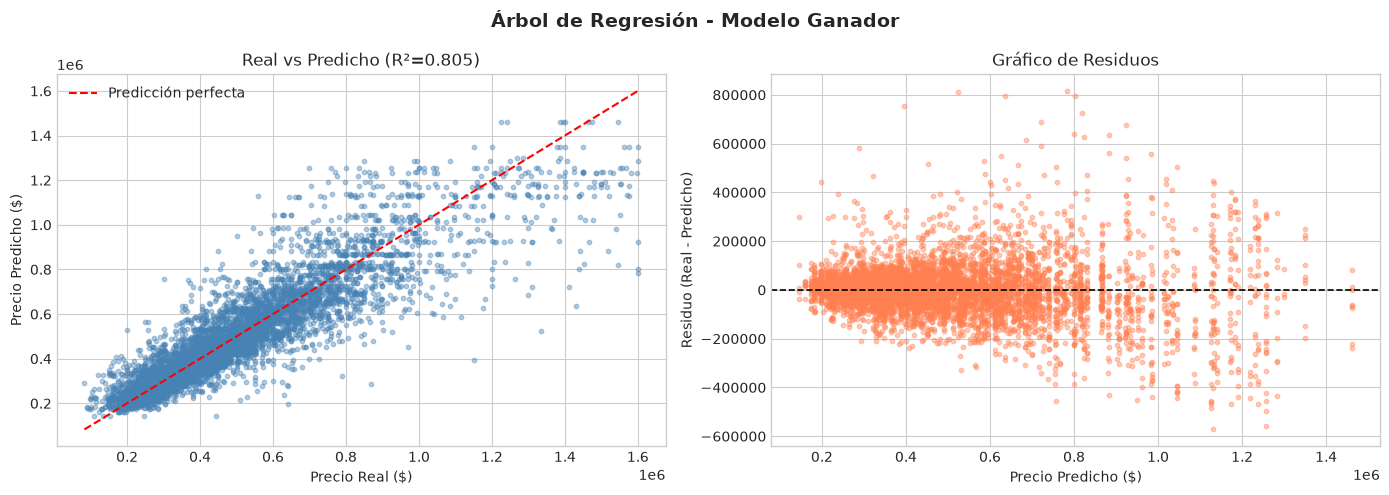

In [18]:
# Árbol de Regresión - Valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Real vs Predicho
axes[0].scatter(y_test, y_pred_tree, alpha=0.4, color='steelblue', s=10)
min_val = min(y_test.min(), y_pred_tree.min())
max_val = max(y_test.max(), y_pred_tree.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real ($)')
axes[0].set_ylabel('Precio Predicho ($)')
axes[0].set_title(f'Real vs Predicho (R²={r2_tree:.3f})')
axes[0].legend()

# Gráfico 2: Residuos
residuos = y_test - y_pred_tree
axes[1].scatter(y_pred_tree, residuos, alpha=0.4, color='coral', s=10)
axes[1].axhline(y=0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Precio Predicho ($)')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].set_title('Gráfico de Residuos')

plt.suptitle('Árbol de Regresión - Modelo Ganador', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Real vs Predicho — cada punto es una casa. Si el modelo fuera perfecto, todos los puntos caerían sobre la línea roja diagonal. Cuanto más dispersos estén alrededor de esa línea, mayor el error.

Residuos — muestra la diferencia entre precio real y predicho para cada casa. Idealmente, los residuos deberían distribuirse aleatoriamente alrededor del cero (línea punteada) — si hay patrones (por ejemplo, errores más grandes en precios altos), significa que el modelo no captura bien ese rango.

6. Utilizar métricas de evaluación de regresión, como el Error Cuadrático Medio (MSE),
el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R2), para medir el
rendimiento del modelo, realizar cuadro comparativo indicado en el punto 4, finaliza
con una breve conclusión de a los resultados obtenidos.

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
elastic_params = {'alpha': [0.001, 0.01, 0.1, 1, 10],
'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

tree_params = {'max_depth': [None, 10, 20, 30],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]}

In [19]:
from sklearn.linear_model import Ridge, ElasticNet

# ── Ridge ──────────────────────────────────────────
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = grid_ridge.predict(X_test_scaled)

# ── Lasso (con los params del desafío) ─────────────
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
grid_lasso2 = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
grid_lasso2.fit(X_train_scaled, y_train)
y_pred_lasso2 = grid_lasso2.predict(X_test_scaled)

# ── ElasticNet ─────────────────────────────────────
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_elastic = GridSearchCV(ElasticNet(max_iter=10000), elastic_params, cv=5, scoring='r2')
grid_elastic.fit(X_train_scaled, y_train)
y_pred_elastic = grid_elastic.predict(X_test_scaled)

# ── Árbol (con los params del desafío) ─────────────
tree_params = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_tree2 = GridSearchCV(DecisionTreeRegressor(random_state=42), tree_params, cv=5, scoring='r2')
grid_tree2.fit(X_train_scaled, y_train)
y_pred_tree2 = grid_tree2.predict(X_test_scaled)

print('Mejores hiperparámetros:')
print(f'Ridge:      {grid_ridge.best_params_}')
print(f'Lasso:      {grid_lasso2.best_params_}')
print(f'ElasticNet: {grid_elastic.best_params_}')
print(f'Árbol:      {grid_tree2.best_params_}')

Mejores hiperparámetros:
Ridge:      {'alpha': 10}
Lasso:      {'alpha': 10}
ElasticNet: {'alpha': 0.01, 'l1_ratio': 0.5}
Árbol:      {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [21]:
# Calcular métricas para los 4 modelos
def calcular_metricas(y_test, y_pred, nombre):
    mse = mean_squared_error(y_test, y_pred)
    return {
        'Modelo': nombre,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    }

resultados = pd.DataFrame([
    calcular_metricas(y_test, y_pred_ridge,   'Ridge (alpha=10)'),
    calcular_metricas(y_test, y_pred_lasso2,  'Lasso (alpha=10)'),
    calcular_metricas(y_test, y_pred_elastic, 'ElasticNet (alpha=0.01, l1=0.5)'),
    calcular_metricas(y_test, y_pred_tree2,   'Árbol de Regresión')
])

# Formatear para presentación
resultados_fmt = resultados.copy()
resultados_fmt['MSE']  = resultados['MSE'].apply(lambda x: f'${x:,.0f}')
resultados_fmt['RMSE'] = resultados['RMSE'].apply(lambda x: f'${x:,.0f}')
resultados_fmt['MAE']  = resultados['MAE'].apply(lambda x: f'${x:,.0f}')
resultados_fmt['R²']   = resultados['R²'].apply(lambda x: f'{x:.4f}')

print('=== Comparación de Modelos ===')
print(resultados_fmt.to_string(index=False))

=== Comparación de Modelos ===
                         Modelo             MSE     RMSE     MAE     R²
               Ridge (alpha=10) $18,790,042,473 $137,077 $98,340 0.7079
               Lasso (alpha=10) $18,790,192,420 $137,077 $98,345 0.7079
ElasticNet (alpha=0.01, l1=0.5) $18,789,343,838 $137,074 $98,302 0.7079
             Árbol de Regresión $13,611,773,412 $116,670 $75,724 0.7884


El Árbol de Regresión es el modelo ganador en todas las métricas:

R² de 0.788 vs 0.708 de los 3 modelos lineales — explica un 8% más de varianza.
RMSE de $116,670 vs ~$137,077 — $20,000 menos de error por casa en promedio.
MAE de $75,724 vs ~$98,300 — error típico $22,000 menor.
Los 3 modelos lineales son prácticamente idénticos — Ridge, Lasso y ElasticNet obtienen exactamente R²=0.7079. Esto confirma que la regularización no aporta mejoras significativas en este dataset: con solo 17 variables bien seleccionadas y datos ya limpios, no hay overfitting relevante que corregir.

Por qué gana el Árbol: las relaciones entre variables y precio no son estrictamente lineales. Por ejemplo, grade tiene un efecto "escalonado" en el precio (saltos discretos), y el árbol captura eso mejor que cualquier modelo lineal.